# Função Exponencial

**Módulo:** 02 – Logaritmos

**Pré-requisitos:** [`0201a_potencias_e_raizes.ipynb`](0201a_potencias_e_raizes.ipynb) (potência de expoente real), [`0105a_funcoes.ipynb`](../01_conjuntos_e_funcoes/0105a_funcoes.ipynb) (função, domínio e imagem) e [`0112a_transformacoes_composta_e_inversa.ipynb`](../01_conjuntos_e_funcoes/0112a_transformacoes_composta_e_inversa.ipynb) (função composta e inversa)

**Objetivos de aprendizagem:**
- Definir a função exponencial, reconhecer seu domínio e imagem, e diferenciar os dois comportamentos possíveis (crescente/decrescente) a partir da base.
- Interpretar transformações do gráfico e comparar o crescimento exponencial com o crescimento linear.
- Resolver equações e inequações exponenciais simples, redutíveis a uma base comum.
- Reconhecer, em situações reais (juros compostos, crescimento populacional, meia-vida), um fenômeno modelado por função exponencial.

**Tempo estimado:** 80 a 100 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/02_logaritmos/0202a_funcao_exponencial.ipynb)


## Quantas dobras até a Lua?

Imagine que fosse possível dobrar uma folha de papel comum (com cerca de 0,1 mm de espessura) ao meio, repetidamente — cada dobra duplicando a espessura da pilha. Quantas dobras seriam necessárias para essa pilha de papel alcançar a Lua, a cerca de 384.000 km de distância da Terra?

**Antes de continuar, arrisque um palpite.** Boa parte das pessoas chuta números na casa dos milhares, ou até milhões, de dobras.

A resposta real é **42 dobras**. Ao final deste notebook, você mesmo vai calcular esse número com Python — e vai entender por que nossa intuição erra tanto quando o assunto é crescimento exponencial.

Essa mesma "armadilha" já apareceu na lenda do tabuleiro de xadrez, no notebook anterior — grãos de trigo dobrando a cada casa. Agora vamos estudar esse comportamento formalmente, como uma **função**.

📖 **Leitura complementar:** [Crescimento exponencial](https://pt.wikipedia.org/wiki/Crescimento_exponencial)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    '''Aplica o estilo Nord padrão a um eixo do matplotlib.'''
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


## 1. Definição e Domínio da Função Exponencial

📌 **Definição formal:** a **função exponencial** de base a é a função f: ℝ → ℝ dada por

$$f(x) = a^x, \quad \text{com } a > 0 \text{ e } a \neq 1$$

O **domínio** é ℝ (todo número real), porque, como vimos no notebook anterior, uma potência de base positiva e expoente real está definida para qualquer x — inteiro, racional ou irracional.

As duas restrições sobre a base não são arbitrárias:
- **a > 0:** evita os problemas de existência que aparecem com base negativa e expoente racional (como (-8)^(1/3) x (-8)^(2/6), vistos no notebook anterior).
- **a ≠ 1:** se a = 1, então f(x) = 1ˣ = 1 para todo x — uma função constante, sem o comportamento de crescimento/decrescimento que torna a exponencial interessante.


In [2]:
# Implementando f(x) = a^x para algumas bases e testando em vários x,
# incluindo negativos e nao inteiros -- para conferir que o dominio e mesmo "todo mundo real"
def funcao_exponencial(a: float, x: float) -> float:
    '''Calcula f(x) = a^x, com a > 0 e a != 1.'''
    return a**x


bases_teste = [2, 10, 0.5]
xs_teste = [-3, -0.5, 0, 1, 2.7, 5]

for a in bases_teste:
    valores = [round(funcao_exponencial(a, x), 4) for x in xs_teste]
    print(f"a = {a:>4g}:", dict(zip(xs_teste, valores)))


a =    2: {-3: 0.125, -0.5: 0.7071, 0: 1, 1: 2, 2.7: 6.498, 5: 32}
a =   10: {-3: 0.001, -0.5: 0.3162, 0: 1, 1: 10, 2.7: 501.1872, 5: 100000}
a =  0.5: {-3: 8.0, -0.5: 1.4142, 0: 1.0, 1: 0.5, 2.7: 0.1539, 5: 0.0312}


**Pergunta de checagem:** por que a condição a ≠ 1 é necessária para termos uma função exponencial "de fato interessante"?

🎯 **Aplicação prática:** qualquer fenômeno que "dobra", "triplica" etc. a cada intervalo de tempo fixo (população, investimento, vírus se espalhando) é descrito por uma função desse tipo — vamos ver exemplos específicos no bloco 7.

📖 **Leitura complementar:** [Exponenciação](https://pt.wikipedia.org/wiki/Exponencia%C3%A7%C3%A3o)


## 2. Propriedades, Imagem e Gráfico

📌 **Definição formal:** a **imagem** da função exponencial é ℝ*₊ (os reais positivos), pois aˣ > 0 para todo x real, quando a > 0.

Existem dois comportamentos possíveis, dependendo da base:
- **a > 1:** f é **crescente** — quanto maior x, maior aˣ.
- **0 < a < 1:** f é **decrescente** — quanto maior x, menor aˣ.

💡 **Dica:** duas características do gráfico valem para qualquer base válida:
- Ele sempre passa pelo ponto **(0, 1)**, pois a⁰ = 1.
- Ele nunca toca o eixo x — o eixo x é uma **assíntota horizontal** (y = 0), que a curva se aproxima cada vez mais sem nunca alcançar.


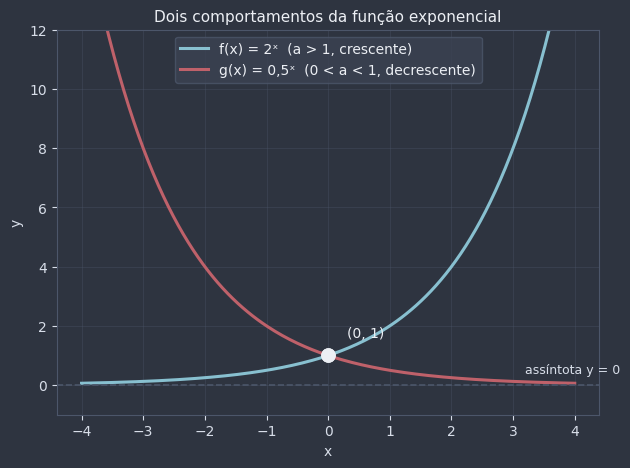

In [3]:
# Plotando duas exponenciais no mesmo gráfico: uma com a > 1 (crescente)
# e outra com 0 < a < 1 (decrescente), destacando (0, 1) e a assíntota
xs = np.linspace(-4, 4, 200)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

ax.plot(xs, 2**xs, color=COR_PONTO, linewidth=2.2, label="f(x) = 2ˣ  (a > 1, crescente)")
ax.plot(xs, 0.5**xs, color=COR_ALERTA, linewidth=2.2, label="g(x) = 0,5ˣ  (0 < a < 1, decrescente)")

ax.scatter([0, 0], [1, 1], s=90, color=NORD_TEXTO, zorder=5)
ax.annotate("(0, 1)", xy=(0, 1), xytext=(0.3, 1.6), color=NORD_TEXTO, fontsize=10)
ax.axhline(0, color=NORD_LINHA, linewidth=1.2, linestyle="--")
ax.text(3.2, 0.4, "assíntota y = 0", color=NORD_TEXTO_SEC, fontsize=9)

ax.set_xlabel("x", color=NORD_TEXTO_SEC)
ax.set_ylabel("y", color=NORD_TEXTO_SEC)
ax.set_ylim(-1, 12)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=10)
ax.set_title("Dois comportamentos da função exponencial", color=NORD_TEXTO, fontsize=11)
plt.show()


🕹️ **Widget interativo:** mexa no slider da base a e observe o gráfico mudar de crescente para decrescente conforme a cruza o valor 1.


In [4]:
def explorar_base(a: float) -> None:
    xs = np.linspace(-4, 4, 200)
    ys = a**xs

    fig, ax = plt.subplots(figsize=(7, 4.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    cor = COR_PONTO if a > 1 else COR_ALERTA
    comportamento = "crescente" if a > 1 else "decrescente"
    ax.plot(xs, ys, color=cor, linewidth=2.2)
    ax.scatter([0], [1], s=90, color=NORD_TEXTO, zorder=5)
    ax.axhline(0, color=NORD_LINHA, linewidth=1.2, linestyle="--")
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel(f"{a:g}ˣ", color=NORD_TEXTO_SEC)
    ax.set_ylim(-1, 15)
    ax.set_title(f"f(x) = {a:g}ˣ  —  {comportamento}", color=cor, fontsize=11)
    plt.show()


widgets.interact(
    explorar_base,
    a=widgets.FloatSlider(value=2.0, min=0.1, max=4.0, step=0.1, description="a:"),
)


interactive(children=(FloatSlider(value=2.0, description='a:', max=4.0, min=0.1), Output()), _dom_classes=('wi…

<function __main__.explorar_base(a: float) -> None>

**Pergunta de checagem:** por que o gráfico de aˣ nunca toca o eixo x, mesmo crescendo (ou decrescendo) indefinidamente?

🎯 **Aplicação prática:** a valorização de um investimento ao longo do tempo (a > 1) e a desvalorização de um carro com o uso (0 < a < 1) são dois exemplos do cotidiano — um de cada comportamento.


## 3. Transformações do Gráfico

💡 **Dica:** a partir de f(x) = aˣ, algumas transformações simples produzem efeitos previsíveis no gráfico:

| Transformação | Efeito |
|---|---|
| f(x) + k | desloca o gráfico **verticalmente** (a assíntota vai de y=0 para y=k) |
| f(x + k) | desloca o gráfico **horizontalmente** |
| c · f(x) | **escala** o gráfico verticalmente (c > 1 estica, 0 < c < 1 comprime) |
| f(-x) | **reflete** o gráfico em torno do eixo y |


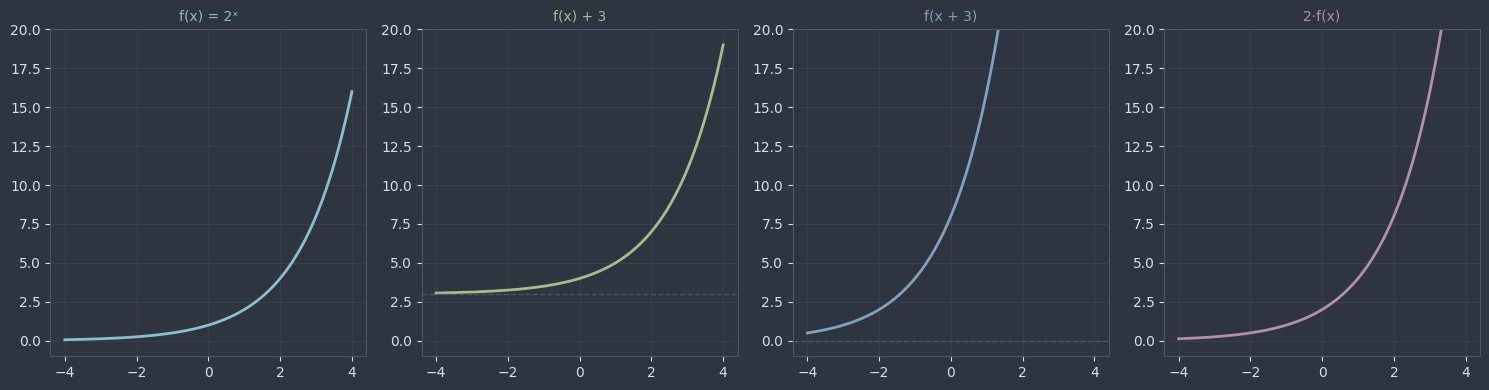

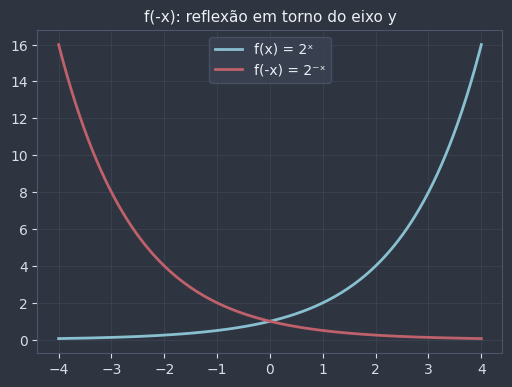

In [5]:
# Comparando f(x) = a^x com suas variações lado a lado
a = 2
xs = np.linspace(-4, 4, 200)
k, c = 3, 2

fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharey=False)
fig.patch.set_facecolor(NORD_FUNDO)

configuracoes = [
    (a**xs, "f(x) = 2ˣ", COR_PONTO, None),
    (a**xs + k, f"f(x) + {k}", COR_DESTAQUE, k),
    (a ** (xs + k), f"f(x + {k})", COR_SECUNDARIA, 0),
    (c * a**xs, f"{c}·f(x)", COR_EXTRA, None),
]

for ax, (ys, titulo, cor, assintota) in zip(axs, configuracoes):
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=cor, linewidth=2)
    if assintota is not None:
        ax.axhline(assintota, color=NORD_LINHA, linewidth=1, linestyle="--")
    ax.set_title(titulo, color=cor, fontsize=10)
    ax.set_ylim(-1, 20)

plt.tight_layout()
plt.show()

# f(-x) em destaque separado, por ter domínio simétrico ao original
fig, ax = plt.subplots(figsize=(6, 4.2))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs, a**xs, color=COR_PONTO, linewidth=2, label="f(x) = 2ˣ")
ax.plot(xs, a ** (-xs), color=COR_ALERTA, linewidth=2, label="f(-x) = 2⁻ˣ")
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA)
ax.set_title("f(-x): reflexão em torno do eixo y", color=NORD_TEXTO, fontsize=11)
plt.show()


🕹️ **Widget interativo:** mexa nos sliders de k (deslocamento) e c (escala) e observe o gráfico de aˣ se transformando em tempo real.


In [6]:
def explorar_transformacoes(k: float, c: float) -> None:
    a = 2
    xs = np.linspace(-4, 4, 200)

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, a**xs, color=NORD_LINHA, linewidth=1.5, linestyle=":", label="f(x) = 2ˣ (original)")
    ax.plot(xs, c * a**xs + k, color=COR_DESTAQUE, linewidth=2.2, label=f"{c:g}·f(x) + {k:g}")
    ax.axhline(k, color=COR_ALERTA, linewidth=1, linestyle="--", label=f"assíntota y = {k:g}")

    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("y", color=NORD_TEXTO_SEC)
    ax.set_ylim(-8, 25)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
    plt.show()


widgets.interact(
    explorar_transformacoes,
    k=widgets.FloatSlider(value=0.0, min=-8.0, max=8.0, step=0.5, description="k:"),
    c=widgets.FloatSlider(value=1.0, min=0.2, max=3.0, step=0.1, description="c:"),
)


interactive(children=(FloatSlider(value=0.0, description='k:', max=8.0, min=-8.0, step=0.5), FloatSlider(value…

<function __main__.explorar_transformacoes(k: float, c: float) -> None>

**Pergunta de checagem:** o que acontece com a assíntota horizontal quando somamos uma constante k à função aˣ?

🎯 **Aplicação prática:** a Lei do Resfriamento de Newton usa exatamente uma exponencial deslocada verticalmente — a temperatura de um objeto tende à temperatura ambiente, não a zero.

📖 **Leitura complementar:** [Decaimento exponencial](https://pt.wikipedia.org/wiki/Decaimento_exponencial)


## 4. Comparação com Crescimento Linear

⚠️ **Erro comum:** achar que, se uma exponencial começa "atrás" de uma reta, ela vai continuar atrás.

A diferença fundamental é como cada uma cresce a cada passo:
- **Crescimento linear:** soma uma quantidade **fixa** a cada intervalo.
- **Crescimento exponencial:** multiplica por um fator **fixo** a cada intervalo.

No longo prazo, **toda exponencial crescente ultrapassa qualquer função linear** — não importa quão devagar ela cresça no começo, nem quão "na frente" a reta esteja de largada. Nossa intuição tende a subestimar isso porque estamos acostumados a raciocinar de forma linear (o chamado **viés de pensamento linear**).


In [7]:
# Comparando f(x) = 2x + 10 (linear) com g(x) = 1.1^x (exponencial)
def linear(x):
    return 2 * x + 10


def exponencial(x):
    return 1.1**x


tabela = pd.DataFrame({"x": range(0, 121, 20)})
tabela["linear (2x+10)"] = linear(tabela["x"])
tabela["exponencial (1,1ˣ)"] = exponencial(tabela["x"]).round(2)
display(tabela)

# Encontrando o primeiro x inteiro em que a exponencial ultrapassa a linear
x = 0
while exponencial(x) <= linear(x):
    x += 1
print(f"\na exponencial ultrapassa a linear em x = {x}")
print(f"linear({x}) = {linear(x):.2f}   exponencial({x}) = {exponencial(x):.2f}")


,x,linear (2x+10),"exponencial (1,1ˣ)"
0,0,10,1.00
1,20,50,6.73
2,40,90,45.26
3,60,130,304.48
4,80,170,2048.40
5,100,210,13780.61
6,120,250,92709.07



a exponencial ultrapassa a linear em x = 50
linear(50) = 110.00   exponencial(50) = 117.39


🕹️ **Widget interativo:** mexa nos sliders do coeficiente angular da reta e da base da exponencial, e veja em que ponto as duas curvas se cruzam.


In [8]:
def explorar_linear_vs_exponencial(coef_angular: float, base: float) -> None:
    xs = np.linspace(0, 30, 300)
    ys_linear = coef_angular * xs + 10
    ys_exp = base**xs

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys_linear, color=COR_SECUNDARIA, linewidth=2, label=f"linear: {coef_angular:g}x + 10")
    ax.plot(xs, ys_exp, color=COR_DESTAQUE, linewidth=2, label=f"exponencial: {base:g}ˣ")
    ax.set_ylim(0, 400)
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("y", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
    plt.show()


widgets.interact(
    explorar_linear_vs_exponencial,
    coef_angular=widgets.FloatSlider(value=2.0, min=0.5, max=15.0, step=0.5, description="coef. angular:"),
    base=widgets.FloatSlider(value=1.1, min=1.01, max=1.5, step=0.01, description="base:"),
)


interactive(children=(FloatSlider(value=2.0, description='coef. angular:', max=15.0, min=0.5, step=0.5), Float…

<function __main__.explorar_linear_vs_exponencial(coef_angular: float, base: float) -> None>

**Pergunta de checagem:** mesmo que uma função exponencial cresça mais devagar no começo, por que ela sempre acaba ultrapassando qualquer função linear, dado tempo suficiente?

🎯 **Aplicação prática:** revisitando a lenda do tabuleiro de xadrez (notebook anterior) — "o rei dar sempre 1 grão a mais por casa" é crescimento linear; "dobrar a cada casa" é crescimento exponencial. É exatamente essa diferença que explica por que o rei quebrou.

📖 **Leitura complementar:** [Sessa ibn Daher](https://pt.wikipedia.org/wiki/Sessa_ibn_Daher)


## 5. Equações Exponenciais (base igual)

📌 **Definição formal:** como f(x) = aˣ é **injetora** (cada valor de x gera um valor diferente de y), vale a propriedade:

$$a^x = a^y \iff x = y \quad (a > 0,\ a \neq 1)$$

Ou seja, se conseguirmos escrever os dois lados de uma equação exponencial como potências de uma **mesma base**, podemos simplesmente igualar os expoentes.


In [9]:
# Resolvendo equacoes exponenciais reduzindo a uma base comum, com sympy
# para conferir cada resultado
x = sp.symbols("x")

# a) 2^x = 32  ->  2^x = 2^5  ->  x = 5
eq_a = sp.Eq(2**x, 32)
sol_a = sp.solve(sp.Eq(x, sp.log(32, 2)))
print("a) 2^x = 32   ->  x =", sp.log(32, 2), "=", sp.nsimplify(sp.log(32, 2)))

# b) 9^x = 27  ->  (3^2)^x = 3^3  ->  3^(2x) = 3^3  ->  2x = 3  ->  x = 3/2
print("b) 9^x = 27   ->  3^(2x) = 3^3  ->  x =", sp.Rational(3, 2))

# c) 4^x = 1/8  ->  (2^2)^x = 2^-3  ->  2^(2x) = 2^-3  ->  2x = -3  ->  x = -3/2
print("c) 4^x = 1/8  ->  2^(2x) = 2^-3  ->  x =", sp.Rational(-3, 2))

# Conferindo os três resultados diretamente
print("\nconferindo:")
print("2^5 =", 2**5, " (esperado 32)")
print("9^(3/2) =", 9 ** sp.Rational(3, 2), " (esperado 27)")
print("4^(-3/2) =", float(4 ** sp.Rational(-3, 2)), " (esperado 0.125)")


a) 2^x = 32   ->  x = 5 = 5
b) 9^x = 27   ->  3^(2x) = 3^3  ->  x = 3/2
c) 4^x = 1/8  ->  2^(2x) = 2^-3  ->  x = -3/2

conferindo:
2^5 = 32  (esperado 32)
9^(3/2) = 27  (esperado 27)
4^(-3/2) = 0.125  (esperado 0.125)


**Pergunta de checagem:** por que podemos "cancelar" as bases iguais e comparar apenas os expoentes?

🎯 **Aplicação prática:** calcular em quantos períodos uma população dobra, quando os números batem exatamente com potências da base — o caso "de sorte", que ainda não precisa de logaritmo.


## 6. Inequações Exponenciais (base igual)

⚠️ **Erro comum:** aplicar a mesma regra das equações para inequações, sem prestar atenção no comportamento da base.

A ideia é parecida, mas com um cuidado importante:
- Se **a > 1** (função crescente): aˣ < aʸ implica **x < y** (o sentido se mantém).
- Se **0 < a < 1** (função decrescente): aˣ < aʸ implica **x > y** (o sentido **se inverte**!).

Essa regra vai reaparecer, de forma mais geral, no notebook de inequações exponenciais e logarítmicas do módulo.


In [10]:
# Resolvendo inequações exponenciais reduzindo a uma base comum
x = sp.symbols("x")

# a) 2^x > 8  ->  2^x > 2^3  ->  como a=2>1, mantem o sentido  ->  x > 3
print("a) 2^x > 8    ->  2^x > 2^3  (a=2 > 1, mantém o sentido)  ->  x > 3")

# b) (1/2)^x < 8  ->  (1/2)^x < (1/2)^-3  ->  como a=1/2<1, inverte o sentido  ->  x > -3
print("b) (1/2)^x < 8  ->  (1/2)^x < (1/2)^(-3)  (a=1/2 < 1, INVERTE)  ->  x > -3")

# Conferindo numericamente perto da fronteira de cada caso
print("\nconferindo a):", [round(2**valor, 2) for valor in (2.9, 3.0, 3.1)], "(cresce com x)")
print("conferindo b):", [round(0.5**valor, 2) for valor in (-3.1, -3.0, -2.9)], "(decresce com x)")


a) 2^x > 8    ->  2^x > 2^3  (a=2 > 1, mantém o sentido)  ->  x > 3
b) (1/2)^x < 8  ->  (1/2)^x < (1/2)^(-3)  (a=1/2 < 1, INVERTE)  ->  x > -3

conferindo a): [7.46, 8.0, 8.57] (cresce com x)
conferindo b): [8.57, 8.0, 7.46] (decresce com x)


🕹️ **Widget interativo:** escolha a base e observe, olhando o gráfico, por que o sentido da desigualdade se inverte quando 0 < a < 1.


In [ ]:
def explorar_inversao_inequacao(a: float) -> None:
    xs = np.linspace(-4, 4, 200)
    ys = a**xs
    x1, x2 = -1, 2

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    cor = COR_PONTO if a > 1 else COR_ALERTA
    ax.plot(xs, ys, color=cor, linewidth=2.2)
    ax.scatter([x1, x2], [a**x1, a**x2], s=90, color=NORD_TEXTO, zorder=5)
    ax.annotate(f"a^{x1} = {a**x1:.2f}", xy=(x1, a**x1), xytext=(x1 - 3.5, a**x1 + 1), color=NORD_TEXTO)
    ax.annotate(f"a^{x2} = {a**x2:.2f}", xy=(x2, a**x2), xytext=(x2 + 0.3, a**x2 + 1), color=NORD_TEXTO)

    if a > 1:
        relacao = f"como {x1} < {x2}, a^{x1} < a^{x2}: sentido MANTIDO (função crescente)"
    else:
        relacao = f"como {x1} < {x2}, mas a^{x1} > a^{x2}: sentido INVERTIDO (função decrescente)"
    ax.set_title(relacao, color=cor, fontsize=10)
    ax.set_ylim(-1, 12)
    plt.show()


widgets.interact(
    explorar_inversao_inequacao,
    a=widgets.FloatSlider(value=2.0, min=0.1, max=4.0, step=0.1, description="a:"),
)


interactive(children=(FloatSlider(value=2.0, description='a:', max=4.0, min=0.1), Output()), _dom_classes=('wi…

<function __main__.explorar_inversao_inequacao(a: float) -> None>

**Pergunta de checagem:** olhando o gráfico de uma exponencial decrescente, por que faz sentido que a desigualdade "vire" quando comparamos os expoentes?

🎯 **Aplicação prática:** decidir a partir de quanto tempo a quantidade de um medicamento no corpo (que decai exponencialmente) cai abaixo de um limite seguro.


## 7. Aplicações: Juros Compostos, Crescimento Populacional e Meia-Vida

📌 **Definição formal:** três modelos clássicos, todos construídos sobre a mesma função exponencial:

$$M = C \cdot (1+i)^t \quad \text{(juros compostos)}$$

$$P(t) = P_0 \cdot a^t \quad \text{(crescimento populacional)}$$

$$Q(t) = Q_0 \cdot \left(\frac{1}{2}\right)^{t / t_{1/2}} \quad \text{(decaimento radioativo / meia-vida)}$$

📎 **Conexão:** apesar dos nomes e contextos diferentes, os três são **matematicamente a mesma função** — algo inicial (C, P₀ ou Q₀) multiplicado por uma base elevada a um expoente proporcional ao tempo.


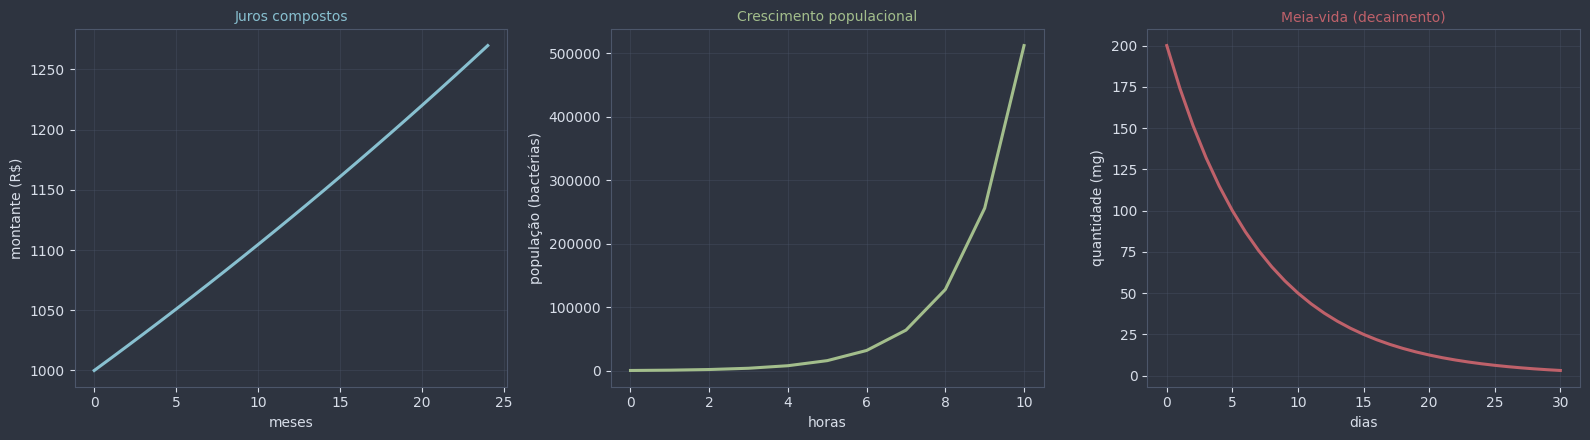

juros: após 24 meses, R$1000 viram R$1269.73
população: após 10h, 500 bactérias viram 512000
meia-vida: após 30 dias, 200mg viram 3.12mg


In [12]:
# Modelo 1: juros compostos -- um investimento de R$1000 a 1% ao mes, por 24 meses
capital, taxa_mensal, meses = 1000, 0.01, 24
tempos_juros = np.arange(0, meses + 1)
montante = capital * (1 + taxa_mensal) ** tempos_juros

# Modelo 2: crescimento populacional -- uma cultura de bacterias que dobra a cada hora
pop_inicial, razao_pop, horas = 500, 2, 10
tempos_pop = np.arange(0, horas + 1)
populacao = pop_inicial * razao_pop**tempos_pop

# Modelo 3: meia-vida -- substância radioativa com meia-vida de 5 dias
quantidade_inicial, meia_vida, dias = 200, 5, 30
tempos_decaimento = np.arange(0, dias + 1)
quantidade = quantidade_inicial * (0.5) ** (tempos_decaimento / meia_vida)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)

dados = [
    (tempos_juros, montante, "Juros compostos", "meses", "montante (R$)", COR_PONTO),
    (tempos_pop, populacao, "Crescimento populacional", "horas", "população (bactérias)", COR_DESTAQUE),
    (tempos_decaimento, quantidade, "Meia-vida (decaimento)", "dias", "quantidade (mg)", COR_ALERTA),
]
for ax, (t, y, titulo, xlabel, ylabel, cor) in zip(axs, dados):
    estilizar_eixo(ax)
    ax.plot(t, y, color=cor, linewidth=2.2)
    ax.set_title(titulo, color=cor, fontsize=10)
    ax.set_xlabel(xlabel, color=NORD_TEXTO_SEC)
    ax.set_ylabel(ylabel, color=NORD_TEXTO_SEC)

plt.tight_layout()
plt.show()

print(f"juros: após {meses} meses, R${capital} viram R${montante[-1]:.2f}")
print(f"população: após {horas}h, {pop_inicial} bactérias viram {populacao[-1]:.0f}")
print(f"meia-vida: após {dias} dias, {quantidade_inicial}mg viram {quantidade[-1]:.2f}mg")


In [13]:
# Resolvendo o desafio do gancho: quantas dobras de uma folha de 0,1mm
# são necessárias para alcançar a Lua (384.000 km)?
espessura_inicial_mm = 0.1
distancia_lua_mm = 384_000 * 1000 * 1000  # km -> m -> mm

dobras = 0
espessura = espessura_inicial_mm
historico = [(dobras, espessura)]
while espessura < distancia_lua_mm:
    dobras += 1
    espessura *= 2  # cada dobra MULTIPLICA a espessura por 2 -- é a chave exponencial
    historico.append((dobras, espessura))

print(f"após {dobras} dobras, a pilha de papel mede {espessura / 1_000_000:.0f} km")
print(f"(distância até a Lua: {distancia_lua_mm / 1_000_000:.0f} km)")

tabela_dobras = pd.DataFrame(historico[-5:], columns=["dobras", "espessura (mm)"])
tabela_dobras["espessura (km)"] = (tabela_dobras["espessura (mm)"] / 1_000_000).round(1)
display(tabela_dobras)


após 42 dobras, a pilha de papel mede 439805 km
(distância até a Lua: 384000 km)


,dobras,espessura (mm),espessura (km)
0,38,2.748779e+10,27487.8
1,39,5.497558e+10,54975.6
2,40,1.099512e+11,109951.2
3,41,2.199023e+11,219902.3
4,42,4.398047e+11,439804.7


🕹️ **Widget interativo:** escolha o modelo (juros / população / meia-vida) e mexa nos parâmetros para ver a curva mudar.


In [ ]:
def simulador_exponencial(modelo: str, valor_inicial: float, taxa_ou_base: float, periodo: int) -> None:
    t = np.arange(0, periodo + 1)

    if modelo == "juros compostos":
        y = valor_inicial * (1 + taxa_ou_base) ** t
        titulo, xlabel, ylabel = "Juros compostos", "período", "montante"
    elif modelo == "crescimento populacional":
        y = valor_inicial * taxa_ou_base**t
        titulo, xlabel, ylabel = "Crescimento populacional", "período", "população"
    else:
        y = valor_inicial * (0.5) ** (t / taxa_ou_base)
        titulo, xlabel, ylabel = "Meia-vida (decaimento)", "período", "quantidade"

    fig, ax = plt.subplots(figsize=(7, 4.8))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(t, y, color=COR_DESTAQUE, linewidth=2.2, marker="o", markersize=3)
    ax.set_title(f"{titulo}: {y[-1]:.2f} após {periodo} períodos", color=COR_DESTAQUE, fontsize=10)
    ax.set_xlabel(xlabel, color=NORD_TEXTO_SEC)
    ax.set_ylabel(ylabel, color=NORD_TEXTO_SEC)
    plt.show()


widgets.interact(
    simulador_exponencial,
    modelo=widgets.Dropdown(
        options=["juros compostos", "crescimento populacional", "meia-vida"],
        value="juros compostos",
        description="modelo:",
    ),
    valor_inicial=widgets.FloatSlider(value=1000.0, min=10.0, max=5000.0, step=10.0, description="valor inicial:"),
    taxa_ou_base=widgets.FloatSlider(value=0.01, min=0.01, max=3.0, step=0.01, description="taxa / base:"),
    periodo=widgets.IntSlider(value=24, min=1, max=60, step=1, description="período:"),
)


interactive(children=(Dropdown(description='modelo:', options=('juros compostos', 'crescimento populacional', …

<function __main__.simulador_exponencial(modelo: str, valor_inicial: float, taxa_ou_base: float, periodo: int) -> None>

**Pergunta de checagem:** o que os três modelos (juros, população, meia-vida) têm em comum matematicamente, apesar de parecerem tão diferentes na prática?

🎯 **Aplicação prática:** a **Regra de 72** — um atalho para estimar rapidamente, sem calculadora científica, em quanto tempo um investimento dobra de valor a uma dada taxa de juros: basta dividir 72 pela taxa (em %).

📖 **Leitura complementar:** [Meia-vida](https://pt.wikipedia.org/wiki/Meia-vida) · [Juro](https://pt.wikipedia.org/wiki/Juro) · [Regra de 72](https://pt.wikipedia.org/wiki/Regra_de_72)


## 8. Gancho final: Desfazendo a Exponencial, Rumo ao Logaritmo

📎 **Conexão:** e se soubermos o **resultado** e quisermos descobrir o **expoente**? Por exemplo: "depois de quantos anos um investimento dobra de valor, a uma taxa de 7% ao ano?"

Esse tipo de pergunta não pode ser resolvido com as técnicas vistas neste notebook — a menos que os números batam certinho com uma base comum. Precisamos de uma operação nova, o **logaritmo**, que "desfaz" a exponencial — assim como a função inversa desfaz uma função (a mesma ideia de função composta e inversa vista em `0112a_transformacoes_composta_e_inversa.ipynb`).


In [15]:
# Uma equação exponencial que NÃO e redutível a uma base comum
x = sp.symbols("x")
equacao = sp.Eq(2**x, 10)
print("equação:", equacao)
print("2^3 =", 2**3, " (menor que 10)")
print("2^4 =", 2**4, " (maior que 10)")
print("\na solução existe (entre 3 e 4), mas nenhuma das técnicas deste notebook")
print("encontra o valor exato de x -- isso fica para o próximo notebook: Logaritmo.")


equação: Eq(2**x, 10)
2^3 = 8  (menor que 10)
2^4 = 16  (maior que 10)

a solução existe (entre 3 e 4), mas nenhuma das técnicas deste notebook
encontra o valor exato de x -- isso fica para o próximo notebook: Logaritmo.


🕹️ **Widget interativo:** mexa no slider de k e observe onde a reta horizontal y = k cruza a curva aˣ — em que x isso acontece? (ainda sem resposta — é só a pergunta visual que abre o próximo notebook.)


In [ ]:
def explorar_cruzamento(k: float) -> None:
    a = 2
    xs = np.linspace(-1, 5, 200)
    ys = a**xs

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, ys, color=COR_PONTO, linewidth=2.2, label="f(x) = 2ˣ")
    ax.axhline(k, color=COR_AVISO, linewidth=2, linestyle="--", label=f"y = {k:g}")
    ax.set_xlabel("x", color=NORD_TEXTO_SEC)
    ax.set_ylabel("y", color=NORD_TEXTO_SEC)
    ax.set_ylim(0, 32)
    ax.set_title("Em que x a reta cruza a curva? (resposta no próximo notebook)", color=NORD_TEXTO, fontsize=10)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, edgecolor=NORD_LINHA, fontsize=9)
    plt.show()


widgets.interact(
    explorar_cruzamento,
    k=widgets.FloatSlider(value=10.0, min=1.0, max=30.0, step=0.5, description="k:"),
)


interactive(children=(FloatSlider(value=10.0, description='k:', max=30.0, min=1.0, step=0.5), Output()), _dom_…

<function __main__.explorar_cruzamento(k: float) -> None>

**Pergunta de checagem:** se a função exponencial "transforma" x em aˣ, que tipo de função "desfaria" essa transformação?

📖 **Leitura complementar:** [Logaritmo](https://pt.wikipedia.org/wiki/Logaritmo)


## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| f(x) = aˣ | a > 0 e a ≠ 1; domínio = ℝ; imagem = ℝ*₊ |
| Gráfico | sempre passa por (0, 1); assíntota horizontal em y = 0; nunca toca o eixo x |
| Comportamento | a > 1 → crescente \| 0 < a < 1 → decrescente |
| Transformações | f(x)+k desloca vertical \| f(x+k) desloca horizontal \| c·f(x) escala \| f(-x) reflete em y |
| Linear x exponencial | linear soma valor fixo, exponencial multiplica por fator fixo — exponencial sempre ultrapassa, no longo prazo |
| Equação: aˣ = aʸ | ⟺ x = y (a > 0, a ≠ 1) |
| Inequação: aˣ < aʸ | ⟺ x < y se a > 1, mas x > y se 0 < a < 1 (sentido inverte!) |
| Modelos clássicos | juros compostos M=C(1+i)ᵗ \| população P(t)=P₀aᵗ \| meia-vida Q(t)=Q₀(1/2)^(t/meia-vida) |
| Próximo passo | para "desfazer" a exponencial e descobrir o expoente, precisamos do **logaritmo** |


## Exercícios

**Básico**
1. Determine o domínio e a imagem de duas funções exponenciais, e classifique-as como crescente ou decrescente.
2. Esboce (numericamente) o comportamento de f(x) = 3ˣ, identificando o ponto (0,1) e a assíntota.

**Intermediário**
3. Resolva duas equações exponenciais redutíveis a uma base comum.
4. Resolva duas inequações exponenciais, uma com base > 1 e outra com base entre 0 e 1.

**Desafio**
5. Um investimento de juros compostos deve dobrar de valor — descubra em quantos períodos isso ocorre, testando se a resposta é redutível a uma base comum.

Gabarito completo com resolução passo a passo em [`0202b_funcao_exponencial_gabarito.ipynb`](0202b_funcao_exponencial_gabarito.ipynb) — tente resolver sozinho antes de olhar.


### Básico

In [ ]:
# Exercício Básico 1: para as funções f(x) = 5^x e g(x) = (1/3)^x, determine:
# - o dominio de cada uma (como string, "R")
# - a imagem de cada uma (como string, "R*+")
# - se cada uma e crescente ou decrescente (como string, "crescente" ou "decrescente")
# Preencha as variáveis abaixo.
dominio_f = ...
imagem_f = ...
comportamento_f = ...

dominio_g = ...
imagem_g = ...
comportamento_g = ...

print(dominio_f, imagem_f, comportamento_f)
print(dominio_g, imagem_g, comportamento_g)


In [ ]:
# Verificação
assert dominio_f == "R" and dominio_g == "R", (
    "Tente de novo, revise: o domínio de qualquer função exponencial é R "
    "(seção 1 - Definição e Domínio)."
)
assert imagem_f == "R*+" and imagem_g == "R*+", (
    "Tente de novo, revise: a imagem de qualquer função exponencial é R*+ "
    "(seção 2 - Propriedades, Imagem e Gráfico)."
)
assert comportamento_f == "crescente", (
    "Tente de novo, revise: f(x)=5^x tem base 5 > 1, logo é crescente "
    "(seção 2 - Propriedades, Imagem e Gráfico)."
)
assert comportamento_g == "decrescente", (
    "Tente de novo, revise: g(x)=(1/3)^x tem base entre 0 e 1, logo é decrescente "
    "(seção 2 - Propriedades, Imagem e Gráfico)."
)
print("Certo!")


In [ ]:
# Exercício Básico 2: para f(x) = 3^x, calcule f(0) e diga por qual ponto fixo
# o gráfico de QUALQUER função exponencial passa (como tupla (x, y)).
# Calcule tambem o limite do gráfico quando x fica bem negativo: para que valor
# y se aproxima, sem nunca alcançar (a assíntota horizontal)?
f_de_zero = ...
ponto_fixo = ...
assintota_y = ...

print(f_de_zero, ponto_fixo, assintota_y)


In [ ]:
# Verificação
assert f_de_zero == 1, "Tente de novo, revise: a^0 = 1 para qualquer base válida (seção 1 - Definição)."
assert ponto_fixo == (0, 1), (
    "Tente de novo, revise: o gráfico de qualquer aˣ passa por (0, 1), pois a⁰=1 "
    "(seção 2 - Propriedades, Imagem e Gráfico)."
)
assert assintota_y == 0, (
    "Tente de novo, revise: a assíntota horizontal do gráfico de aˣ é sempre y=0 "
    "(seção 2 - Propriedades, Imagem e Gráfico)."
)
print("Certo!")


### Intermediário

In [ ]:
# Exercício Intermediário 3: resolva as equações exponenciais reduzindo a uma
# base comum.
# a) 5^x = 125
# b) 8^x = 1/2
solucao_3a = ...
solucao_3b = ...

print(solucao_3a, solucao_3b)


In [ ]:
# Verificação
assert solucao_3a == 3, (
    "Tente de novo, revise: 5^x = 125 = 5^3, logo x=3 (seção 5 - Equações Exponenciais)."
)
assert abs(float(solucao_3b) - (-1 / 3)) < 1e-9, (
    "Tente de novo, revise: 8^x = 1/2 = 2^-1, e 8 = 2^3, logo 2^(3x)=2^-1, "
    "3x=-1, x=-1/3 (seção 5 - Equações Exponenciais)."
)
print("Certo!")


In [ ]:
# Exercício Intermediário 4: resolva as inequações exponenciais reduzindo a
# uma base comum. Preencha com uma string no formato "x > valor" ou "x < valor"
# (use números, sem frações, ex: "x > 2" ou "x < -1.5").
# a) 3^x > 81      (base 3, maior que 1)
# b) (1/4)^x < 16  (base 1/4, entre 0 e 1 -- cuidado com o sentido!)
solucao_4a = ...
solucao_4b = ...

print(solucao_4a)
print(solucao_4b)


In [ ]:
# Verificação
assert solucao_4a.replace(" ", "") == "x>4", (
    "Tente de novo, revise: 3^x > 81 = 3^4, base 3 > 1 mantém o sentido, "
    "logo x > 4 (seção 6 - Inequações Exponenciais)."
)
assert solucao_4b.replace(" ", "") == "x>-2", (
    "Tente de novo, revise: (1/4)^x < 16 = (1/4)^-2, base 1/4 < 1 INVERTE o "
    "sentido, logo x > -2 (seção 6 - Inequações Exponenciais)."
)
print("Certo!")


### Desafio

In [ ]:
# Exercício Desafio 5: um investimento de R$1000, com juros compostos de 25% ao
# período, deve DOBRAR de valor. Calcule o menor número inteiro de períodos
# necessário para que o montante ultrapasse R$2000 (dobre o capital inicial),
# testando período a período (não existe base comum exata para 2 aqui).
capital_ex5 = 1000
taxa_ex5 = 0.25

periodos_para_dobrar = ...

print(periodos_para_dobrar, capital_ex5 * (1 + taxa_ex5) ** periodos_para_dobrar)


In [ ]:
# Verificação
periodos_esperado = 0
while capital_ex5 * (1 + taxa_ex5) ** periodos_esperado < 2 * capital_ex5:
    periodos_esperado += 1

assert periodos_para_dobrar == periodos_esperado, (
    "Tente de novo, revise: teste M = 1000*(1,25)^t período a período até M "
    "ultrapassar 2000 -- repare que 2 não é uma potência exata de 1,25, "
    "então não dá pra resolver por base comum (seção 8 - Gancho final)."
)
print("Certo!")


## Glossário do bloco

| Termo | Definição |
|---|---|
| Função exponencial | f(x) = aˣ, com a > 0 e a ≠ 1, definida para todo x real |
| Base | o número a que é elevado ao expoente x na função aˣ |
| Assíntota horizontal | reta que o gráfico se aproxima cada vez mais, sem nunca tocar |
| Crescimento exponencial | crescimento em que a quantidade é multiplicada por um fator fixo a cada intervalo |
| Viés de pensamento linear | tendência de subestimar o crescimento exponencial, raciocinando como se ele fosse linear |
| Meia-vida | tempo necessário para uma quantidade radioativa se reduzir à metade |


## Conexões

**Isso depende de:**
- [`0201a_potencias_e_raizes.ipynb`](0201a_potencias_e_raizes.ipynb) (potência de expoente real)
- [`0105a_funcoes.ipynb`](../01_conjuntos_e_funcoes/0105a_funcoes.ipynb) (função, domínio/imagem)
- [`0112a_transformacoes_composta_e_inversa.ipynb`](../01_conjuntos_e_funcoes/0112a_transformacoes_composta_e_inversa.ipynb) (função composta e inversa)

**Isso será usado em:**
- 📌 Logaritmo (próximo notebook deste módulo — o logaritmo é definido como a operação que desfaz a exponencial)
- 📌 Função Logarítmica (função logarítmica como inversa da exponencial)
- 📌 Inequações Exponenciais e Logarítmicas (regra de inversão do sinal, generalizada)
- [`10_matematica_financeira_comercial_e_estatistica_descritiva/`](../10_matematica_financeira_comercial_e_estatistica_descritiva/) (juros compostos)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (a função exponencial reaparece com o número e)
